# House Price Prediction - Support Vector Regression (SVR)
**Dataset:** Kaggle House Prices Dataset  
**Link:** https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data  
**Algorithm:** Support Vector Regression (SVR)  
**Metrics:** MAE, RMSE, R²

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline


## 2. Load Dataset

In [3]:
# Load dataset
df = pd.read_csv("../../data/train.csv")

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (1460, 81)

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Exploratory Data Analysis (EDA)

In [4]:
# Basic statistics
print('Dataset Info:')
print(df.info())
print('\nBasic Statistics:')
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  Overa

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


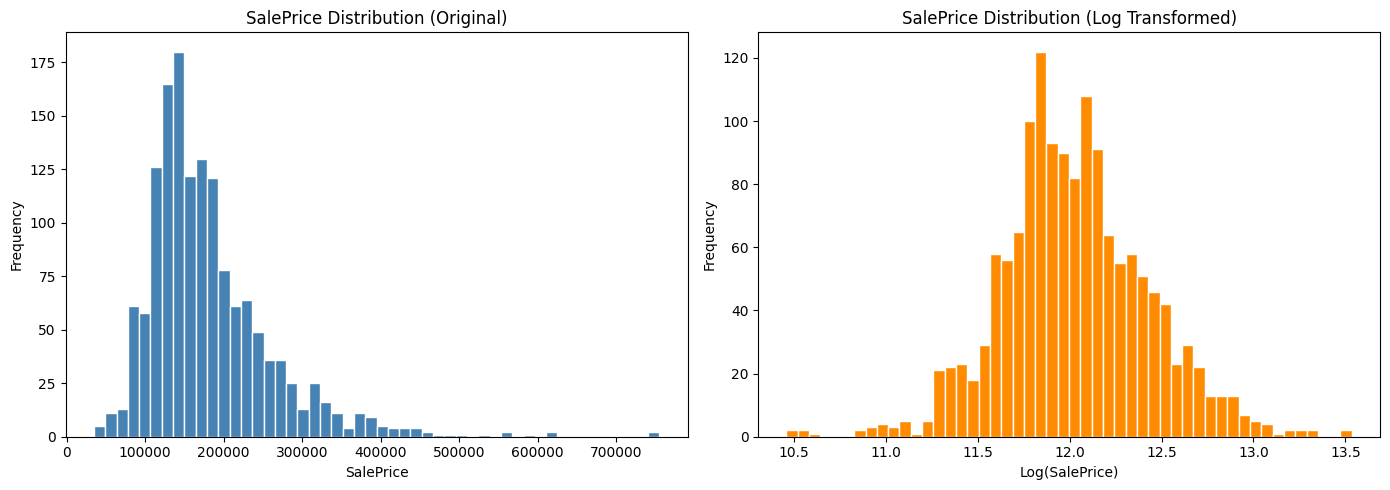

In [5]:
# Distribution of target variable (SalePrice)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before log transformation
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice Distribution (Original)')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Frequency')

# After log transformation
axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('SalePrice Distribution (Log Transformed)')
axes[1].set_xlabel('Log(SalePrice)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('svr_saleprice_distribution.png', dpi=150)
plt.show()

In [6]:
# Top 15 features correlated with SalePrice
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()
top_corr = corr['SalePrice'].abs().sort_values(ascending=False).head(15)
print('Top 15 Features Correlated with SalePrice:')
print(top_corr)

Top 15 Features Correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


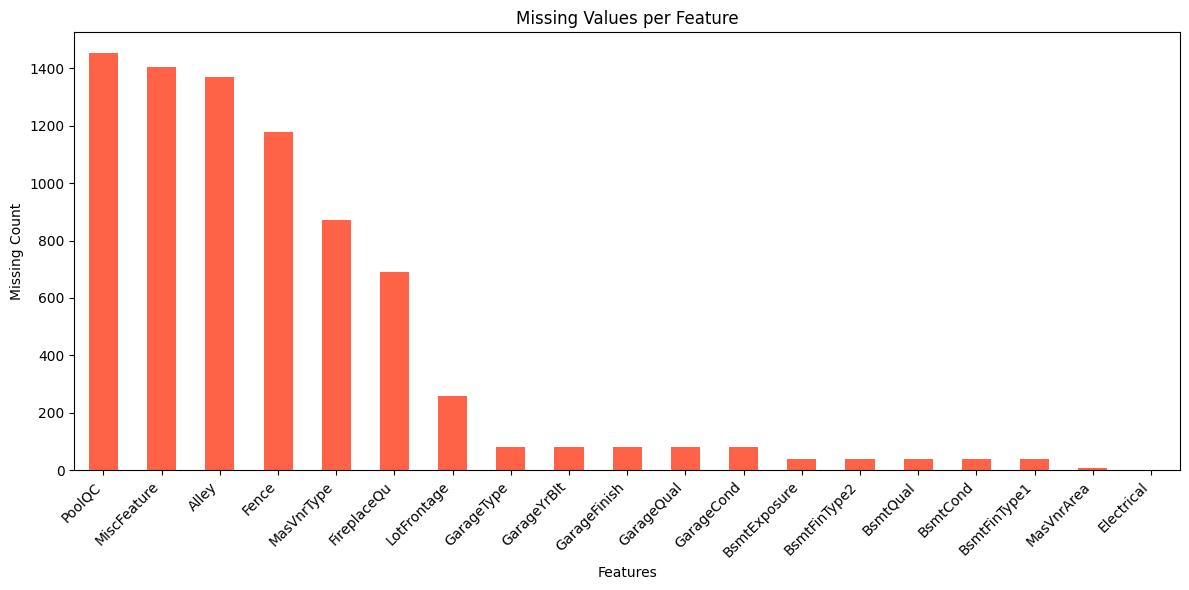

Total features with missing values: 19


In [7]:
# Visualize missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
missing.plot(kind='bar', color='tomato')
plt.title('Missing Values per Feature')
plt.xlabel('Features')
plt.ylabel('Missing Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('svr_missing_values.png', dpi=150)
plt.show()

print(f'Total features with missing values: {len(missing)}')

## 4. Data Preprocessing

In [8]:
# Drop ID column - not a predictive feature
df.drop('Id', axis=1, inplace=True)

# Apply log transformation to target to reduce skewness
df['SalePrice'] = np.log1p(df['SalePrice'])

# Separate features and target
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

print('Feature Matrix Shape:', X.shape)
print('Target Shape:', y.shape)

Feature Matrix Shape: (1460, 79)
Target Shape: (1460,)


In [9]:
# -------------------------------------------------------
# Handle Missing Values
# -------------------------------------------------------

# Categorical: fill with 'None' (feature is absent)
cat_cols_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in cat_cols_none:
    if col in X.columns:
        X[col] = X[col].fillna('None')

# Categorical: fill with mode
cat_cols_mode = ['Electrical', 'MSZoning', 'KitchenQual', 'Exterior1st',
                 'Exterior2nd', 'Functional', 'SaleType']
for col in cat_cols_mode:
    if col in X.columns:
        X[col] = X[col].fillna(X[col].mode()[0])

# Numeric: fill with 0 (no feature present)
num_cols_zero = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for col in num_cols_zero:
    if col in X.columns:
        X[col] = X[col].fillna(0)

# LotFrontage: fill with neighborhood median (similar houses nearby)
X['LotFrontage'] = X.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

print('Missing values after cleaning:', X.isnull().sum().sum())

Missing values after cleaning: 0


In [10]:
# -------------------------------------------------------
# Feature Engineering
# -------------------------------------------------------

# Create meaningful composite features
X['TotalSF']    = X['TotalBsmtSF'] + X['1stFlrSF'] + X['2ndFlrSF']   # Total living area
X['TotalBath']  = (X['FullBath'] + 0.5 * X['HalfBath'] +
                   X['BsmtFullBath'] + 0.5 * X['BsmtHalfBath'])        # Weighted bathrooms
X['HouseAge']   = X['YrSold'] - X['YearBuilt']                         # Age at point of sale
X['RemodAge']   = X['YrSold'] - X['YearRemodAdd']                      # Years since remodel

print('New features added: TotalSF, TotalBath, HouseAge, RemodAge')
print('Updated Feature Matrix Shape:', X.shape)

New features added: TotalSF, TotalBath, HouseAge, RemodAge
Updated Feature Matrix Shape: (1460, 83)


In [11]:
# -------------------------------------------------------
# Encode Categorical Variables
# -------------------------------------------------------

label_encoders = {}
cat_features = X.select_dtypes(include=['object','string']).columns.tolist()

for col in cat_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print(f'Encoded {len(cat_features)} categorical features')
print('Final Feature Matrix Shape:', X.shape)

Encoded 43 categorical features
Final Feature Matrix Shape: (1460, 83)


## 5. Train-Test Split

In [12]:
# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training set size:', X_train.shape)
print('Test set size:    ', X_test.shape)

Training set size: (1168, 83)
Test set size:     (292, 83)


## 6. Background & Justification: SVR

**Support Vector Regression (SVR)** extends Support Vector Machines (SVM) to regression problems. Instead of finding a hyperplane that separates classes, SVR finds a function that deviates from the actual target values by at most **ε (epsilon)** for as many training points as possible, while remaining as flat as possible.

### Why SVR for House Price Prediction?
- Effective in **high-dimensional feature spaces** (80+ features)
- Uses the **kernel trick** to capture non-linear relationships without explicitly transforming features
- Robust to **outliers** — only support vectors influence the model, not all data points
- Works well on **small-to-medium datasets** like this one (~1460 rows)

###  Critical Requirement: Feature Scaling
SVR is **highly sensitive to feature scale**. Unlike tree-based models, SVR computes distances between data points using a kernel. If features are on different scales (e.g., `LotArea` in thousands vs `OverallQual` in 1–10), larger-scale features dominate the distance computation, leading to poor results. **StandardScaler is mandatory** before training SVR.

### Key Hyperparameters
| Parameter | Description |
|---|---|
| `kernel` | The kernel function: `linear`, `poly`, `rbf`, `sigmoid`. `rbf` is most common |
| `C` | Regularization parameter — higher C = less regularization, fits training data more closely |
| `epsilon (ε)` | Width of the insensitive tube — points inside are not penalized |
| `gamma` | Kernel coefficient for `rbf`/`poly` — controls influence of each training point |

## 7. Train the SVR Model

In [13]:
# -------------------------------------------------------
# IMPORTANT: Scale features before SVR
# SVR is sensitive to feature magnitude — StandardScaler is mandatory
# -------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit on train, transform train
X_test_scaled  = scaler.transform(X_test)         # Transform test using train statistics only

print('Features scaled using StandardScaler (mean=0, std=1).')

Features scaled using StandardScaler (mean=0, std=1).


In [14]:
# -------------------------------------------------------
# Baseline SVR Model (RBF kernel, default parameters)
# -------------------------------------------------------
svr_baseline = SVR(kernel='rbf')
svr_baseline.fit(X_train_scaled, y_train)
print('Baseline SVR (RBF kernel) trained successfully.')

Baseline SVR (RBF kernel) trained successfully.


In [15]:
# -------------------------------------------------------
# Kernel Comparison: Linear vs RBF vs Polynomial
# -------------------------------------------------------
kernels = {
    'Linear'     : SVR(kernel='linear'),
    'RBF'        : SVR(kernel='rbf'),
    'Polynomial' : SVR(kernel='poly', degree=3)
}

kernel_results = {}

for name, model in kernels.items():
    model.fit(X_train_scaled, y_train)
    y_pred = np.expm1(model.predict(X_test_scaled))
    y_true = np.expm1(y_test)

    kernel_results[name] = {
        'MAE' : mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2'  : r2_score(y_true, y_pred)
    }
    print(f'{name:12s} -> MAE: ${kernel_results[name]["MAE"]:>10,.0f} | '
          f'RMSE: ${kernel_results[name]["RMSE"]:>10,.0f} | '
          f'R²: {kernel_results[name]["R2"]:.4f}')

Linear       -> MAE: $    16,160 | RMSE: $    24,658 | R²: 0.9207
RBF          -> MAE: $    21,169 | RMSE: $    43,393 | R²: 0.7545
Polynomial   -> MAE: $    23,474 | RMSE: $   103,657 | R²: -0.4008


In [16]:
# -------------------------------------------------------
# Hyperparameter Tuning with GridSearchCV (RBF kernel)
# Using Pipeline to avoid data leakage during CV
# -------------------------------------------------------
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr',    SVR(kernel='rbf'))
])

param_grid = {
    'svr__C'      : [0.1, 1, 10, 100],
    'svr__epsilon': [0.01, 0.1, 0.5],
    'svr__gamma'  : ['scale', 'auto', 0.01, 0.001]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)   # Pass unscaled — pipeline handles scaling

print('\nBest Parameters:', grid_search.best_params_)
print('Best CV RMSE (log scale):', -grid_search.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best Parameters: {'svr__C': 1, 'svr__epsilon': 0.01, 'svr__gamma': 0.001}
Best CV RMSE (log scale): 0.12981236456504744


In [17]:
# Best tuned model (pipeline with scaler + SVR)
best_svr = grid_search.best_estimator_
print('Tuned SVR pipeline ready.')

Tuned SVR pipeline ready.


## 8. Evaluation & Results

In [18]:
# -------------------------------------------------------
# Evaluation Function
# -------------------------------------------------------
def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name='Model', scaled=False):
    """
    Evaluate regression model on train and test sets.
    Set scaled=True if X_tr/X_te are already scaled (for baseline model).
    """
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)

    # Reverse log transform to original dollar scale
    y_tr_orig      = np.expm1(y_tr)
    y_te_orig      = np.expm1(y_te)
    y_tr_pred_orig = np.expm1(y_tr_pred)
    y_te_pred_orig = np.expm1(y_te_pred)

    print(f'\n========== {model_name} ==========')
    print(f'  Train MAE  : ${mean_absolute_error(y_tr_orig, y_tr_pred_orig):,.0f}')
    print(f'  Test  MAE  : ${mean_absolute_error(y_te_orig, y_te_pred_orig):,.0f}')
    print(f'  Train RMSE : ${np.sqrt(mean_squared_error(y_tr_orig, y_tr_pred_orig)):,.0f}')
    print(f'  Test  RMSE : ${np.sqrt(mean_squared_error(y_te_orig, y_te_pred_orig)):,.0f}')
    print(f'  Train R²   : {r2_score(y_tr_orig, y_tr_pred_orig):.4f}')
    print(f'  Test  R²   : {r2_score(y_te_orig, y_te_pred_orig):.4f}')

    return y_te_pred_orig, y_te_orig


# Baseline SVR (uses scaled arrays)
_, _ = evaluate_model(
    svr_baseline, X_train_scaled, X_test_scaled,
    y_train, y_test, 'Baseline SVR (RBF, defaults)', scaled=True
)

# Tuned SVR pipeline (passes raw X — pipeline scales internally)
y_pred_final, y_actual = evaluate_model(
    best_svr, X_train, X_test,
    y_train, y_test, 'Tuned SVR (GridSearchCV Pipeline)'
)


========== Baseline SVR (RBF, defaults) ==========
  Train MAE  : $11,899
  Test  MAE  : $21,169
  Train RMSE : $16,707
  Test  RMSE : $43,393
  Train R²   : 0.9532
  Test  R²   : 0.7545

========== Tuned SVR (GridSearchCV Pipeline) ==========
  Train MAE  : $12,052
  Test  MAE  : $15,357
  Train RMSE : $24,447
  Test  RMSE : $26,116
  Train R²   : 0.8998
  Test  R²   : 0.9111


In [19]:
# -------------------------------------------------------
# 5-Fold Cross Validation on Full Dataset
# -------------------------------------------------------
cv_scores = cross_val_score(
    best_svr, X, y,
    cv=5,
    scoring='r2'
)

print('Cross-Validation R² Scores:', cv_scores.round(4))
print(f'Mean CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Cross-Validation R² Scores: [0.909  0.8779 0.904  0.9116 0.8697]
Mean CV R²: 0.8944 ± 0.0172


## 9. Visualizations

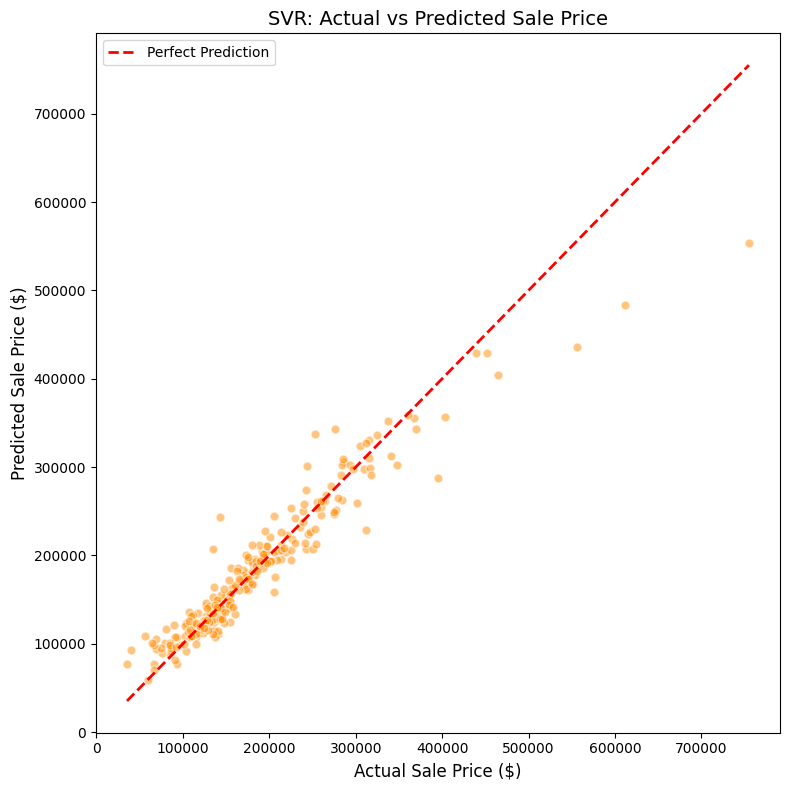

In [20]:
# -------------------------------------------------------
# Plot 1: Actual vs Predicted Prices
# -------------------------------------------------------
plt.figure(figsize=(8, 8))
plt.scatter(y_actual, y_pred_final, alpha=0.5, color='darkorange', edgecolors='white', s=40)

# Perfect prediction reference line
min_val = min(y_actual.min(), y_pred_final.min())
max_val = max(y_actual.max(), y_pred_final.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.title('SVR: Actual vs Predicted Sale Price', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('svr_actual_vs_predicted.png', dpi=150)
plt.show()

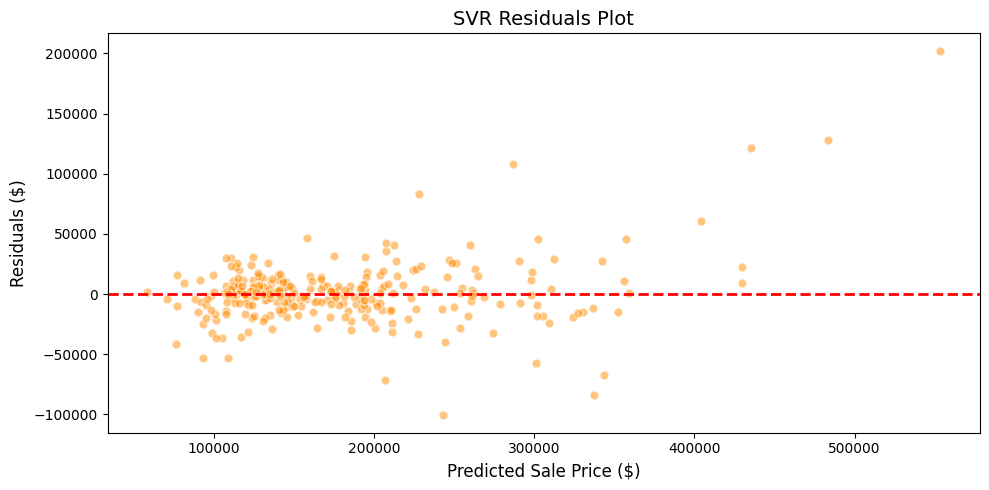

In [21]:
# -------------------------------------------------------
# Plot 2: Residuals Plot
# -------------------------------------------------------
residuals = y_actual - y_pred_final

plt.figure(figsize=(10, 5))
plt.scatter(y_pred_final, residuals, alpha=0.5, color='darkorange', edgecolors='white', s=40)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Sale Price ($)', fontsize=12)
plt.ylabel('Residuals ($)', fontsize=12)
plt.title('SVR Residuals Plot', fontsize=14)
plt.tight_layout()
plt.savefig('svr_residuals.png', dpi=150)
plt.show()

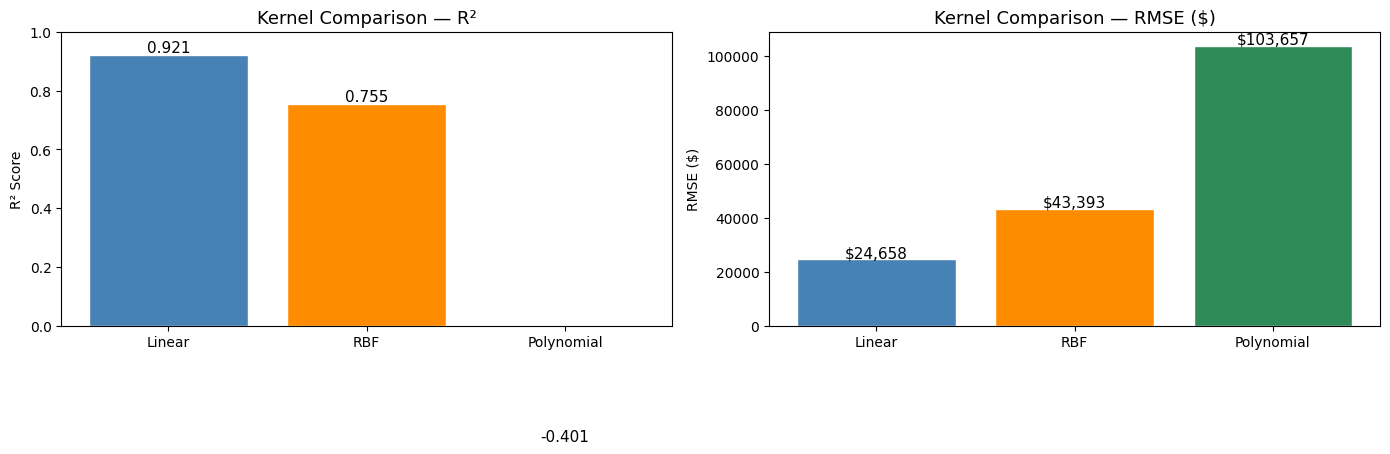

In [22]:
# -------------------------------------------------------
# Plot 3: Kernel Comparison Bar Chart
# -------------------------------------------------------
kernel_names = list(kernel_results.keys())
r2_scores    = [kernel_results[k]['R2']   for k in kernel_names]
rmse_scores  = [kernel_results[k]['RMSE'] for k in kernel_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
axes[0].bar(kernel_names, r2_scores, color=['steelblue', 'darkorange', 'seagreen'], edgecolor='white')
axes[0].set_title('Kernel Comparison — R²', fontsize=13)
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11)

# RMSE comparison
axes[1].bar(kernel_names, rmse_scores, color=['steelblue', 'darkorange', 'seagreen'], edgecolor='white')
axes[1].set_title('Kernel Comparison — RMSE ($)', fontsize=13)
axes[1].set_ylabel('RMSE ($)')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 500, f'${v:,.0f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('svr_kernel_comparison.png', dpi=150)
plt.show()

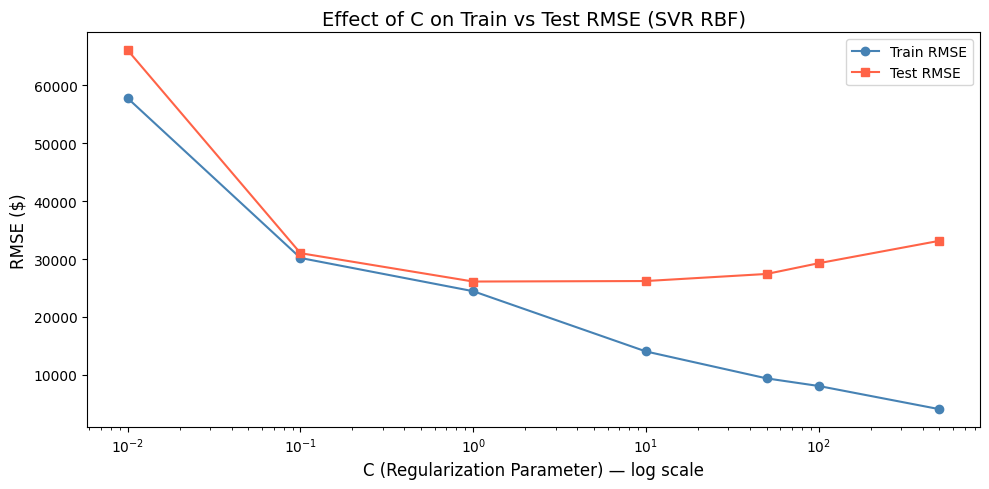

In [23]:
# -------------------------------------------------------
# Plot 4: Effect of C parameter on Train vs Test RMSE
# -------------------------------------------------------
C_values         = [0.01, 0.1, 1, 10, 50, 100, 500]
train_rmse_list  = []
test_rmse_list   = []

# Extract best epsilon and gamma from tuned model
best_eps   = grid_search.best_params_['svr__epsilon']
best_gamma = grid_search.best_params_['svr__gamma']

for c in C_values:
    pipe_temp = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(kernel='rbf', C=c, epsilon=best_eps, gamma=best_gamma))
    ])
    pipe_temp.fit(X_train, y_train)

    train_pred = np.expm1(pipe_temp.predict(X_train))
    test_pred  = np.expm1(pipe_temp.predict(X_test))

    train_rmse_list.append(np.sqrt(mean_squared_error(np.expm1(y_train), train_pred)))
    test_rmse_list.append(np.sqrt(mean_squared_error(np.expm1(y_test),  test_pred)))

plt.figure(figsize=(10, 5))
plt.plot(C_values, train_rmse_list, marker='o', label='Train RMSE', color='steelblue')
plt.plot(C_values, test_rmse_list,  marker='s', label='Test RMSE',  color='tomato')
plt.xscale('log')
plt.xlabel('C (Regularization Parameter) — log scale', fontsize=12)
plt.ylabel('RMSE ($)', fontsize=12)
plt.title('Effect of C on Train vs Test RMSE (SVR RBF)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('svr_C_vs_rmse.png', dpi=150)
plt.show()

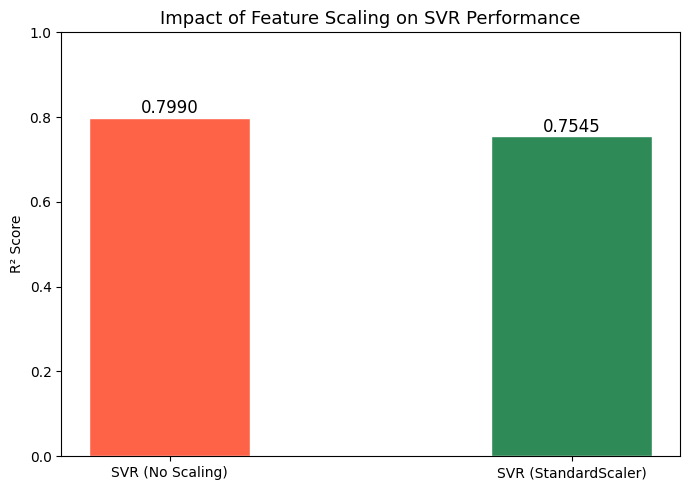

R² without scaling : 0.7990
R² with scaling    : 0.7545


In [24]:
# -------------------------------------------------------
# Plot 5: Effect of Scaling (Scaled vs Unscaled)
# This plot demonstrates WHY scaling matters for SVR
# -------------------------------------------------------
svr_unscaled = SVR(kernel='rbf')
svr_unscaled.fit(X_train, y_train)    # Train directly on unscaled features

y_pred_unscaled = np.expm1(svr_unscaled.predict(X_test))
y_pred_scaled   = np.expm1(svr_baseline.predict(X_test_scaled))
y_true_orig     = np.expm1(y_test)

r2_unscaled = r2_score(y_true_orig, y_pred_unscaled)
r2_scaled   = r2_score(y_true_orig, y_pred_scaled)

labels  = ['SVR (No Scaling)', 'SVR (StandardScaler)']
r2_vals = [r2_unscaled, r2_scaled]
colors  = ['tomato', 'seagreen']

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, r2_vals, color=colors, edgecolor='white', width=0.4)
for bar, val in zip(bars, r2_vals):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
             f'{val:.4f}', ha='center', fontsize=12)
plt.ylim(0, 1)
plt.title('Impact of Feature Scaling on SVR Performance', fontsize=13)
plt.ylabel('R² Score')
plt.tight_layout()
plt.savefig('svr_scaling_impact.png', dpi=150)
plt.show()

print(f'R² without scaling : {r2_unscaled:.4f}')
print(f'R² with scaling    : {r2_scaled:.4f}')

## 10. Summary of Results

In [25]:
# Final summary table comparing baseline vs tuned SVR
y_pred_baseline = np.expm1(svr_baseline.predict(X_test_scaled))
y_true_orig     = np.expm1(y_test)

results = pd.DataFrame({
    'Model': ['Baseline SVR (RBF, defaults)', 'Tuned SVR (GridSearchCV)'],
    'MAE ($)': [
        f"{mean_absolute_error(y_true_orig, y_pred_baseline):,.0f}",
        f"{mean_absolute_error(y_true_orig, y_pred_final):,.0f}"
    ],
    'RMSE ($)': [
        f"{np.sqrt(mean_squared_error(y_true_orig, y_pred_baseline)):,.0f}",
        f"{np.sqrt(mean_squared_error(y_true_orig, y_pred_final)):,.0f}"
    ],
    'R²': [
        f"{r2_score(y_true_orig, y_pred_baseline):.4f}",
        f"{r2_score(y_true_orig, y_pred_final):.4f}"
    ]
})

print('========== Final Results Summary ==========')
print(results.to_string(index=False))

# Kernel comparison summary
print('\n========== Kernel Comparison ==========')
for k, v in kernel_results.items():
    print(f'{k:12s} -> MAE: ${v["MAE"]:>10,.0f} | RMSE: ${v["RMSE"]:>10,.0f} | R²: {v["R2"]:.4f}')

========== Final Results Summary ==========
                       Model MAE ($) RMSE ($)     R²
Baseline SVR (RBF, defaults)  21,169   43,393 0.7545
    Tuned SVR (GridSearchCV)  15,357   26,116 0.9111

========== Kernel Comparison ==========
Linear       -> MAE: $    16,160 | RMSE: $    24,658 | R²: 0.9207
RBF          -> MAE: $    21,169 | RMSE: $    43,393 | R²: 0.7545
Polynomial   -> MAE: $    23,474 | RMSE: $   103,657 | R²: -0.4008


In [29]:
import json, os
os.makedirs("../../results", exist_ok=True)

y_pred = y_pred_final   # already converted in your code
y_true = y_actual

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

results = {
    "model": "svr",
    "RMSE": round(rmse, 2),
    "R2": round(r2, 4)
}

with open("../../results/svr_results.json", "w") as f:
    json.dump(results, f)

print("Results saved!")

Results saved!
